# Smart Irrigation System — ML Model Training
This notebook trains a Random Forest Regressor to predict the irrigation valve angle (0°–120°)  
from soil moisture, temperature, and humidity readings collected by the ESP32 sensor nodes.


## 1. Imports & Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import joblib
import json



## 2. Gateway Constants

In [2]:
# ── Must stay in sync with gateway.ino ─────────────────────────────────────
MOISTURE_DRY = 40.0    # below this → open valve
MOISTURE_WET = 70.0    # above this → close valve
VALVE_MAX    = 120     # max servo angle (degrees)
VALVE_MIN    = 10      # min open angle
VALVE_CLOSED = 0
HUM_HIGH     = 70.0    # high humidity → reduce watering
HUM_LOW      = 30.0    # low humidity  → increase watering
TEMP_HOT     = 33.0    # high temp     → increase watering

In [3]:

def gateway_valve_angle(moisture, humidity, temp):
    """Python replica of handleAutoIrrigation() in gateway.ino."""
    if moisture >= MOISTURE_WET:
        return VALVE_CLOSED
    elif moisture < MOISTURE_DRY:
        dry_ratio = 1.0 - (moisture / MOISTURE_DRY)
        angle_f   = dry_ratio * VALVE_MAX
        if humidity > HUM_HIGH:
            angle_f *= 0.7
        elif humidity < HUM_LOW:
            angle_f *= 1.2
        if temp > TEMP_HOT:
            angle_f *= 1.15
        return int(np.clip(angle_f, VALVE_MIN, VALVE_MAX))
    else:
        band_ratio = 1.0 - ((moisture - MOISTURE_DRY) / (MOISTURE_WET - MOISTURE_DRY))
        return int(np.clip(band_ratio * VALVE_MIN, 0, VALVE_MIN))

print("✓ Gateway logic loaded")
print(f"  Dry threshold : {MOISTURE_DRY}%")
print(f"  Wet threshold : {MOISTURE_WET}%")
print(f"  Valve range   : {VALVE_CLOSED}° – {VALVE_MAX}°")


✓ Gateway logic loaded
  Dry threshold : 40.0%
  Wet threshold : 70.0%
  Valve range   : 0° – 120°


## 3. Generate / Load Dataset

In [4]:
CSV_PATH = "Intial dataset/irrigation_dataset.csv"

In [5]:
def generate_dataset(n_samples=8000, seed=42):
    rng      = np.random.default_rng(seed)
    moisture = rng.beta(2, 2, n_samples) * 100
    temp     = rng.normal(28, 6, n_samples).clip(10, 45)
    humidity = rng.normal(50, 18, n_samples).clip(15, 95)
    hour     = rng.integers(0, 24, n_samples)

    valve_angle = np.array([
        gateway_valve_angle(m, h, t)
        for m, h, t in zip(moisture, humidity, temp)
    ])

    # ── Derived features ────────────────────────────────────────────────────
    moisture_deficit = np.clip(MOISTURE_DRY - moisture, 0, MOISTURE_DRY)
    temp_stress      = np.clip(temp - TEMP_HOT, 0, 15)
    hum_factor       = np.where(humidity > HUM_HIGH, -1,
                        np.where(humidity < HUM_LOW, 1, 0))

    df = pd.DataFrame({
        "moisture":         moisture,
        "temperature":      temp,
        "humidity":         humidity,
        "hour":             hour,
        "moisture_deficit": moisture_deficit,
        "temp_stress":      temp_stress,
        "hum_factor":       hum_factor,
        "valve_angle":      valve_angle,           # ← target
    })

    return df


In [6]:
import os
if os.path.exists(CSV_PATH):
    df = pd.read_csv(CSV_PATH)
    print(f"Loaded existing dataset — {len(df):,} rows")
else:
    df = generate_dataset(8000)
    df.to_csv(CSV_PATH, index=False)
    print(f"Generated & saved — {len(df):,} rows")

df.head()

Loaded existing dataset — 8,000 rows


,moisture,temperature,humidity,hour,moisture_deficit,temp_stress,hum_factor,valve_angle
0,42.454803,16.408679,77.758231,13,0.0,0.000000,-1,9
1,52.758894,39.669328,34.010938,14,0.0,6.669328,0,5
2,63.718018,30.046153,77.153724,4,0.0,0.000000,-1,2
3,51.725491,26.393469,64.668129,22,0.0,0.000000,0,6
4,68.135110,33.419859,46.631028,15,0.0,0.419859,0,0


## 4. Exploratory Data Analysis

In [7]:
print("Dataset shape:", df.shape)
print()
print(df.describe().round(2).to_string())


Dataset shape: (8000, 8)

       moisture  temperature  humidity     hour  moisture_deficit  temp_stress  hum_factor  valve_angle
count   8000.00      8000.00   8000.00  8000.00           8000.00      8000.00     8000.00      8000.00
mean      49.87        27.91     49.89    11.55              5.16         0.67        0.00        17.81
std       22.43         6.01     17.29     6.88              9.09         1.81        0.51        26.67
min        0.40        10.00     15.00     0.00              0.00         0.00       -1.00         0.00
25%       32.69        23.90     37.68     6.00              0.00         0.00        0.00         0.00
50%       49.64        27.89     49.48    12.00              0.00         0.00        0.00         6.00
75%       67.49        31.95     61.78    17.00              7.31         0.00        0.00        21.00
max       99.41        45.00     95.00    23.00             39.60        12.00        1.00       120.00


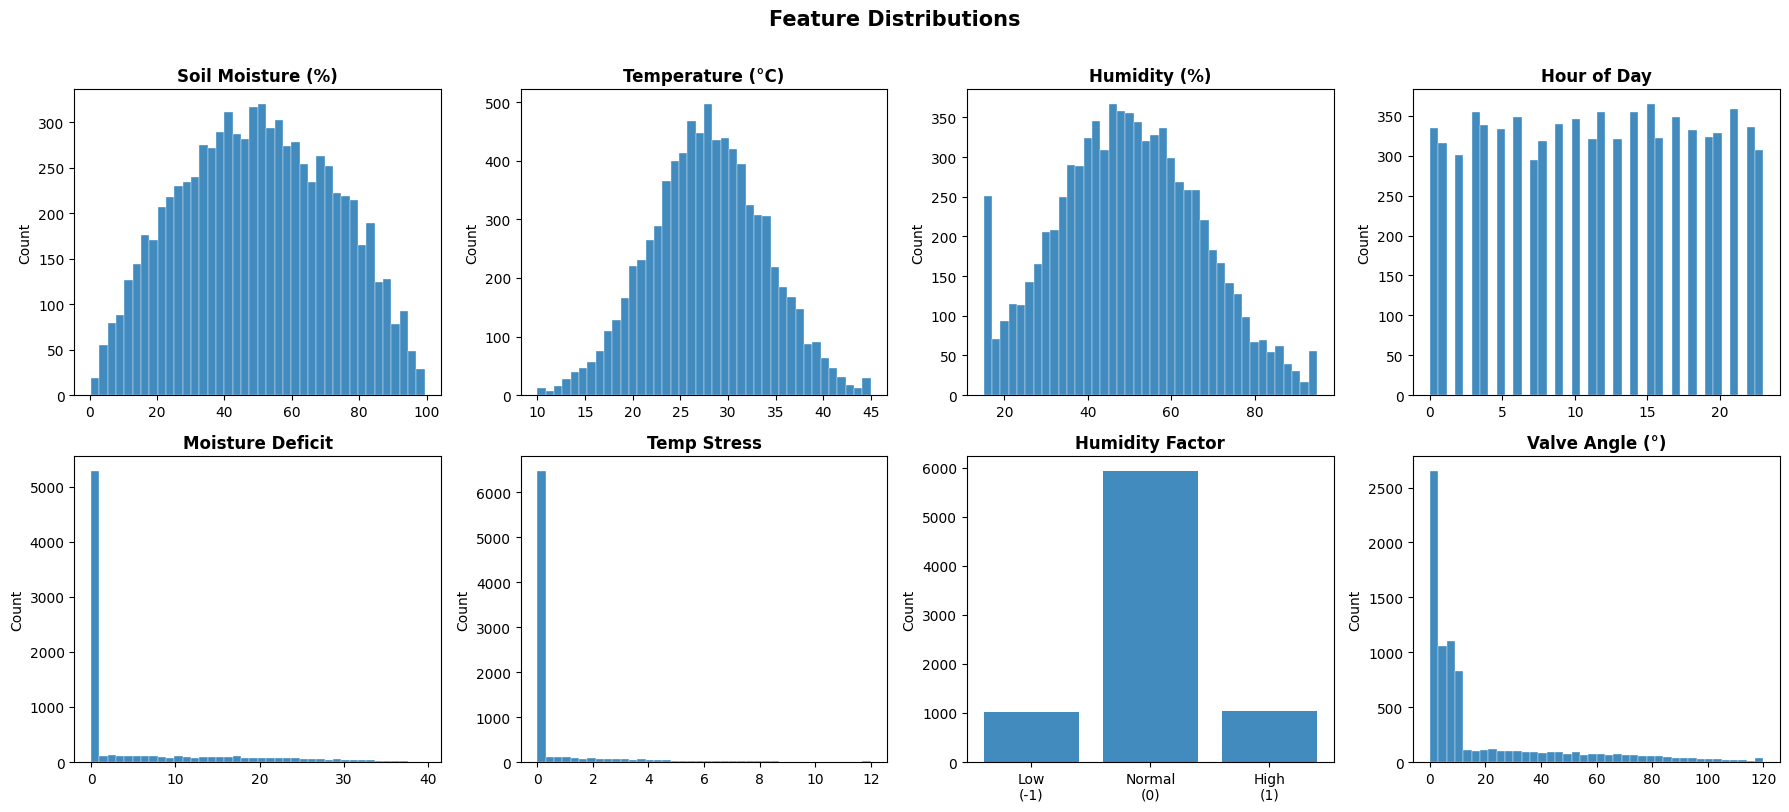

In [8]:
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
fig.suptitle("Feature Distributions", fontsize=15, fontweight="bold", y=1.01)

cols = df.columns
labels = ["Soil Moisture (%)", "Temperature (°C)", "Humidity (%)", "Hour of Day",
          "Moisture Deficit", "Temp Stress", "Humidity Factor", "Valve Angle (°)"]

for ax, col, label in zip(axes.flat, cols, labels):
    if col == "hum_factor":
        counts = df[col].value_counts().sort_index()
        ax.bar(["Low\n(-1)", "Normal\n(0)", "High\n(1)"],
               [counts.get(-1,0), counts.get(0,0), counts.get(1,0)], alpha=0.85)
    else:
        ax.hist(df[col], bins=40, alpha=0.85, edgecolor="white", linewidth=0.3)
    ax.set_title(label, fontweight="bold")
    ax.set_ylabel("Count")

plt.tight_layout()
plt.savefig("figures/01_feature_distributions.png", dpi=150, bbox_inches="tight")
plt.show()

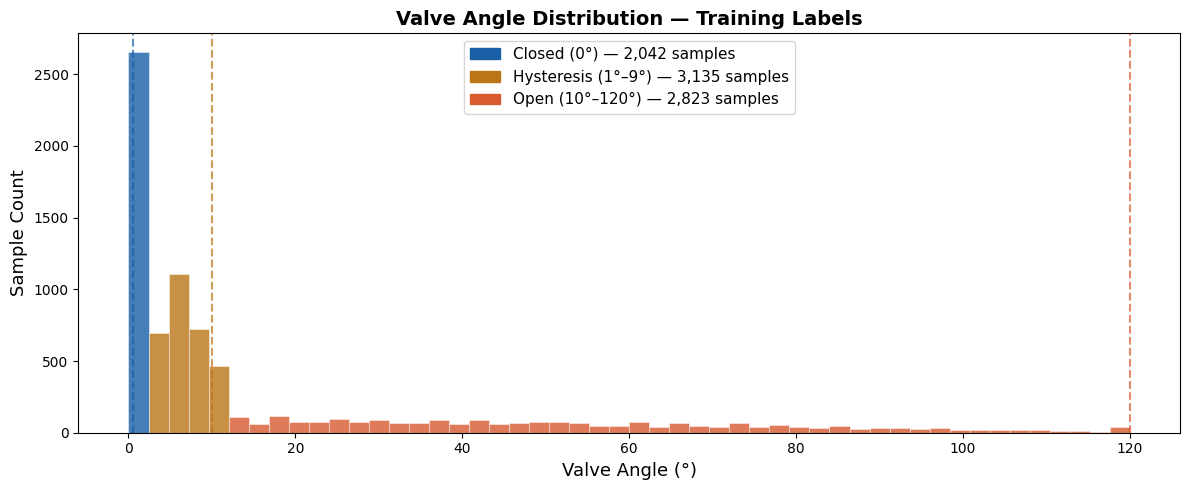

In [9]:
# Valve angle distribution with zone annotations
fig, ax = plt.subplots(figsize=(12, 5))

counts, bins, patches = ax.hist(df["valve_angle"], bins=50,
                                color="#1D9E75", alpha=0.8,
                                edgecolor="white", linewidth=0.4)

# Color zones
for patch, left in zip(patches, bins[:-1]):
    if left == 0:
        patch.set_facecolor("#185FA5")
    elif left < 10:
        patch.set_facecolor("#BA7517")
    else:
        patch.set_facecolor("#D85A30")

ax.axvline(0.5,  color="#185FA5", linestyle="--", linewidth=1.5, alpha=0.7)
ax.axvline(10,   color="#BA7517", linestyle="--", linewidth=1.5, alpha=0.7)
ax.axvline(VALVE_MAX, color="#D85A30", linestyle="--", linewidth=1.5, alpha=0.7)

ax.set_xlabel("Valve Angle (°)", fontsize=13)
ax.set_ylabel("Sample Count",    fontsize=13)
ax.set_title("Valve Angle Distribution — Training Labels", fontsize=14, fontweight="bold")

legend_patches = [
    mpatches.Patch(color="#185FA5", label=f"Closed (0°) — {(df.valve_angle==0).sum():,} samples"),
    mpatches.Patch(color="#BA7517", label=f"Hysteresis (1°–9°) — {((df.valve_angle>0)&(df.valve_angle<10)).sum():,} samples"),
    mpatches.Patch(color="#D85A30", label=f"Open (10°–120°) — {(df.valve_angle>=10).sum():,} samples"),
]
ax.legend(handles=legend_patches, fontsize=11)

plt.tight_layout()
plt.savefig("figures/02_valve_angle_distribution.png", dpi=150, bbox_inches="tight")
plt.show()


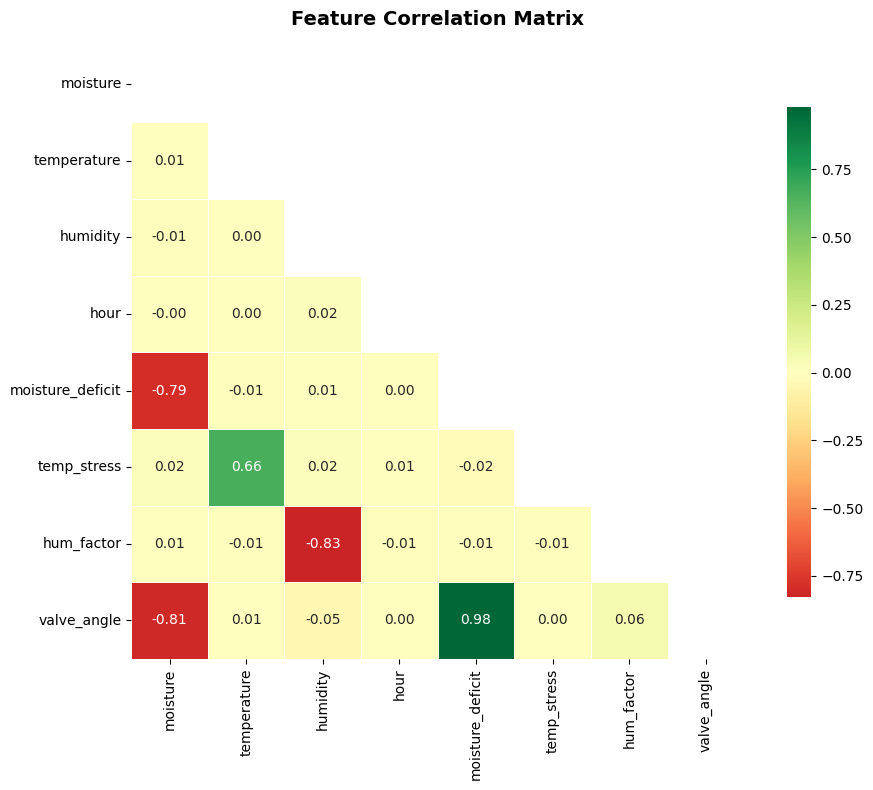

In [10]:
# Correlation heatmap
fig, ax = plt.subplots(figsize=(10, 8))
corr = df.corr().round(2)
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="RdYlGn",
            center=0, ax=ax, square=True, linewidths=0.5,
            cbar_kws={"shrink": 0.8})
ax.set_title("Feature Correlation Matrix", fontsize=14, fontweight="bold", pad=15)
plt.tight_layout()
plt.savefig("figures/03_correlation_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()


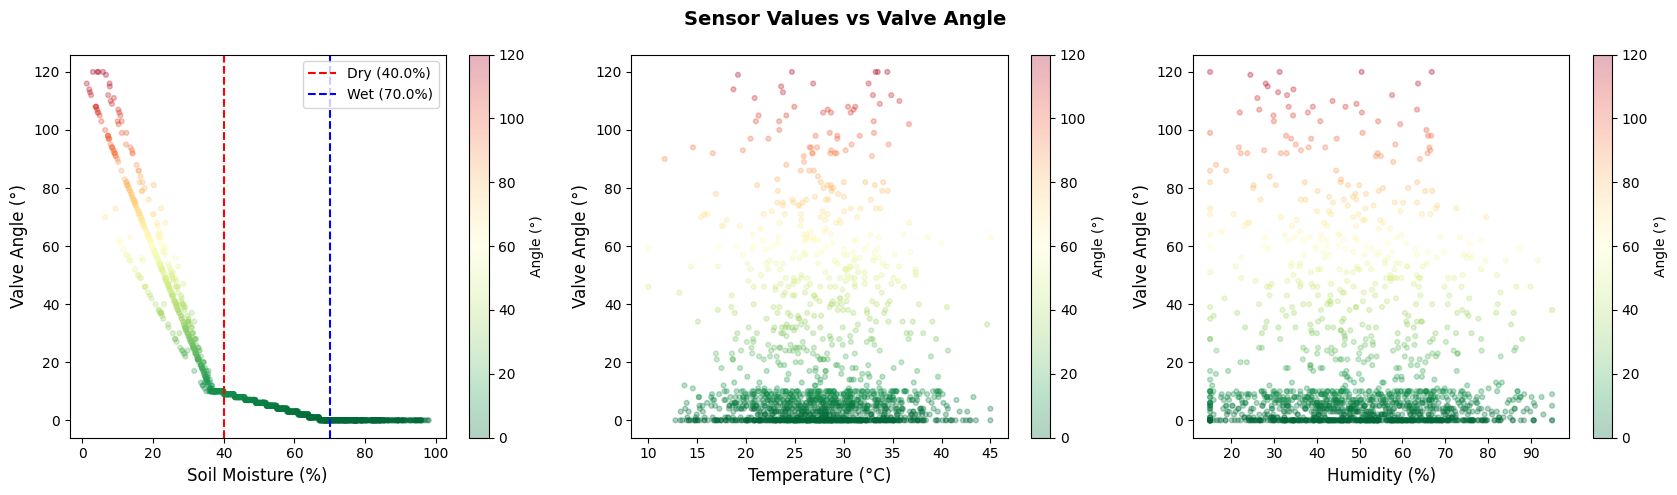

In [11]:
# Moisture vs valve angle scatter — key relationship
fig, axes = plt.subplots(1, 3, figsize=(17, 5))
fig.suptitle("Sensor Values vs Valve Angle", fontsize=14, fontweight="bold")

pairs = [
    ("moisture",    "Soil Moisture (%)"),
    ("temperature", "Temperature (°C)"),
    ("humidity",    "Humidity (%)"),
]
for ax, (xcol, xlabel) in zip(axes, pairs):
    sample = df.sample(1500, random_state=42)
    sc = ax.scatter(sample[xcol], sample["valve_angle"],
                    alpha=0.3, s=12, c=sample["valve_angle"],
                    cmap="RdYlGn_r", vmin=0, vmax=120)
    ax.set_xlabel(xlabel, fontsize=12)
    ax.set_ylabel("Valve Angle (°)", fontsize=12)
    plt.colorbar(sc, ax=ax, label="Angle (°)")

    if xcol == "moisture":
        ax.axvline(MOISTURE_DRY, color="red",  linestyle="--", linewidth=1.5, label=f"Dry ({MOISTURE_DRY}%)")
        ax.axvline(MOISTURE_WET, color="blue", linestyle="--", linewidth=1.5, label=f"Wet ({MOISTURE_WET}%)")
        ax.legend(fontsize=10)

plt.tight_layout()
plt.savefig("figures/04_sensor_vs_valve.png", dpi=150, bbox_inches="tight")
plt.show()


## 5. Model Training
### Random Forest Valve Angle Predictor

In [12]:
from sklearn.model_selection import train_test_split
FEATURE_COLS = [
    "moisture", "temperature", "humidity", "moisture_deficit",'hum_factor'
]

X = df[FEATURE_COLS]
y = df["valve_angle"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print(f"Train samples : {len(X_train):,}")
print(f"Test  samples : {len(X_test):,}")


Train samples : 6,400
Test  samples : 1,600


In [13]:
from sklearn.ensemble   import RandomForestRegressor
rf = RandomForestRegressor(
    n_estimators     = 10,
    max_depth        = None,
    min_samples_leaf = 2,
    max_features     = "sqrt",
    n_jobs           = -1,
    random_state     = 42,
)

rf.fit(X_train, y_train)

,n_estimators,10
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,2
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


## 6. Model Evaluation

In [15]:
from sklearn.metrics import mean_absolute_error, mean_squared_error,r2_score
rf_preds  = rf.predict(X_test).clip(0, 120)
rule_preds = np.array([
    gateway_valve_angle(
        X_test.iloc[i]["moisture"],
        X_test.iloc[i]["humidity"],
        X_test.iloc[i]["temperature"]
    ) for i in range(len(X_test))
])

def metrics(y_true, y_pred, name):
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2   = r2_score(y_true, y_pred)
    print(f"  {name}")
    print(f"    MAE  : {mae:.4f}°")
    print(f"    RMSE : {rmse:.4f}°")
    print(f"    R²   : {r2:.4f}")
    return mae, rmse, r2

print("─" * 45)
rf_mae,   rf_rmse,   rf_r2   = metrics(y_test, rf_preds,   "Random Forest")
print("─" * 45)
rule_mae, rule_rmse, rule_r2 = metrics(y_test, rule_preds, "Rule-Based Gateway")
print("─" * 45)


─────────────────────────────────────────────
  Random Forest
    MAE  : 0.3392°
    RMSE : 0.9279°
    R²   : 0.9988
─────────────────────────────────────────────
  Rule-Based Gateway
    MAE  : 0.0000°
    RMSE : 0.0000°
    R²   : 1.0000
─────────────────────────────────────────────


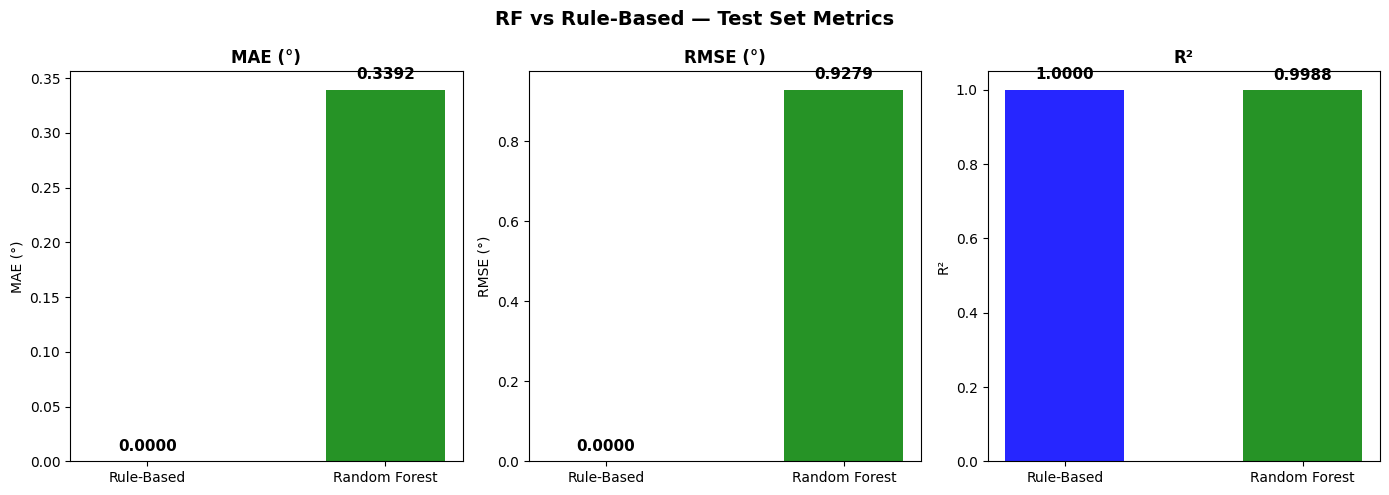

In [16]:
# Side-by-side metrics bar chart
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
fig.suptitle("RF vs Rule-Based — Test Set Metrics", fontsize=14, fontweight="bold")

metric_names = ["MAE (°)", "RMSE (°)", "R²"]
rf_vals      = [rf_mae, rf_rmse, rf_r2]
rule_vals    = [rule_mae, rule_rmse, rule_r2]

for ax, name, rv, mv in zip(axes, metric_names, rule_vals, rf_vals):
    bars = ax.bar(["Rule-Based", "Random Forest"], [rv, mv],
                  color=['blue','green'], alpha=0.85, width=0.5)
    ax.set_title(name, fontweight="bold")
    ax.set_ylabel(name)
    for bar, val in zip(bars, [rv, mv]):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + max(rv, mv)*0.02,
                f"{val:.4f}", ha="center", va="bottom", fontsize=11, fontweight="bold")

plt.tight_layout()
plt.savefig("figures/05_metrics_comparison.png", dpi=150, bbox_inches="tight")
plt.show()


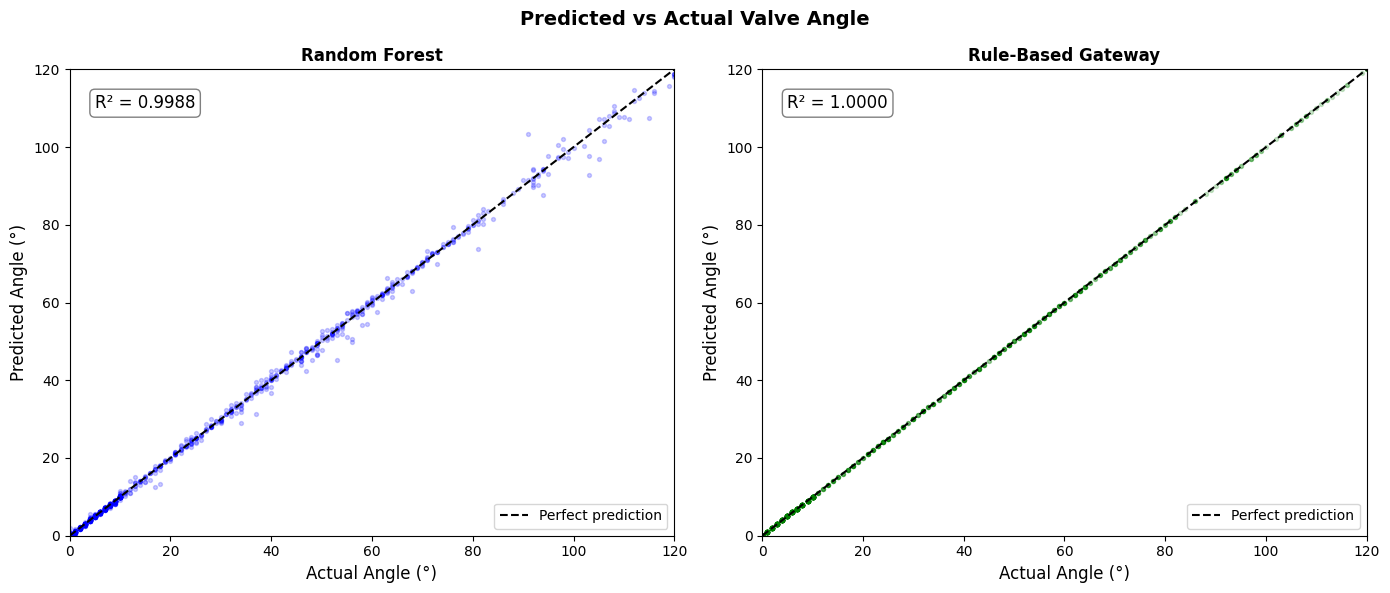

In [17]:
# Predicted vs actual scatter
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle("Predicted vs Actual Valve Angle", fontsize=14, fontweight="bold")

for ax, preds, name, color in zip(
    axes,
    [rf_preds, rule_preds],
    ["Random Forest", "Rule-Based Gateway"],
    ['blue','green']
):
    ax.scatter(y_test, preds, alpha=0.2, s=8, color=color)
    lims = [0, 120]
    ax.plot(lims, lims, "k--", linewidth=1.5, label="Perfect prediction")
    ax.set_xlim(lims); ax.set_ylim(lims)
    ax.set_xlabel("Actual Angle (°)", fontsize=12)
    ax.set_ylabel("Predicted Angle (°)", fontsize=12)
    ax.set_title(name, fontweight="bold")
    ax.legend()
    r2 = r2_score(y_test, preds)
    ax.text(5, 110, f"R² = {r2:.4f}", fontsize=12,
            bbox=dict(boxstyle="round,pad=0.3", facecolor="white", edgecolor="gray"))

plt.tight_layout()
plt.savefig("figures/06_predicted_vs_actual.png", dpi=150, bbox_inches="tight")
plt.show()


## 7. Cross-Validation

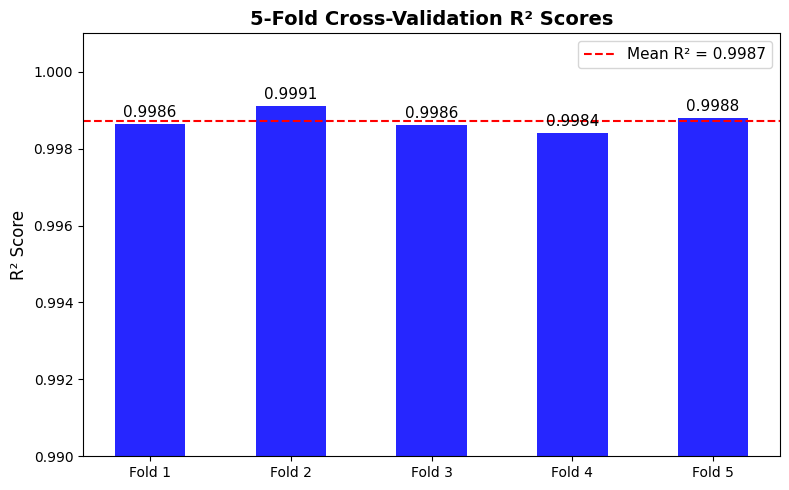

Mean R²: 0.9987 ± 0.0002


In [18]:

from sklearn.model_selection import cross_val_score


cv_scores = cross_val_score(rf, X, y, cv=5, scoring="r2", n_jobs=-1)

fig, ax = plt.subplots(figsize=(8, 5))
folds = [f"Fold {i+1}" for i in range(5)]
bars  = ax.bar(folds, cv_scores, color="blue", alpha=0.85, width=0.5)
ax.axhline(cv_scores.mean(), color="red", linestyle="--", linewidth=1.5,
           label=f"Mean R² = {cv_scores.mean():.4f}")
ax.set_ylim(0.99, 1.001)
ax.set_ylabel("R² Score", fontsize=12)
ax.set_title("5-Fold Cross-Validation R² Scores", fontsize=14, fontweight="bold")
ax.legend(fontsize=11)

for bar, val in zip(bars, cv_scores):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.0001,
            f"{val:.4f}", ha="center", va="bottom", fontsize=11)

plt.tight_layout()
plt.savefig("figures/07_cross_validation.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Mean R²: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")


## 8. Feature Importances

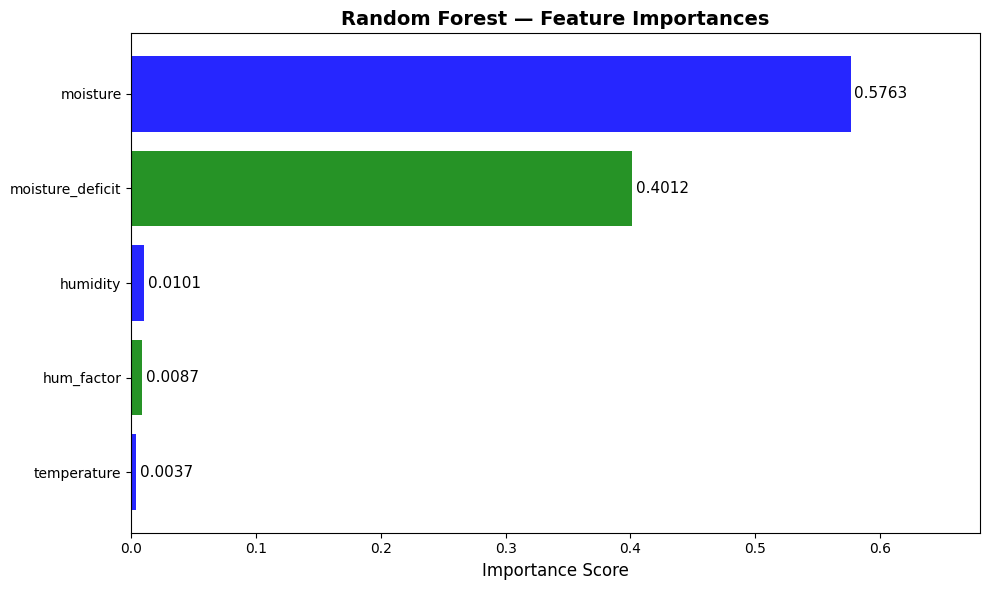

In [19]:
importances = pd.Series(rf.feature_importances_, index=FEATURE_COLS).sort_values()

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(importances.index, importances.values,
               color=['blue','green'], alpha=0.85)

for bar, val in zip(bars, importances.values):
    ax.text(val + 0.003, bar.get_y() + bar.get_height()/2,
            f"{val:.4f}", va="center", fontsize=11)

ax.set_xlabel("Importance Score", fontsize=12)
ax.set_title("Random Forest — Feature Importances", fontsize=14, fontweight="bold")
ax.set_xlim(0, importances.max() * 1.18)

plt.tight_layout()
plt.savefig("figures/08_feature_importances.png", dpi=150, bbox_inches="tight")
plt.show()


## 9. Save Model

In [ ]:
joblib.dump(rf, "Model/rf_valve_model.joblib")

meta = {
    "features":     FEATURE_COLS,
    "target":       "valve_angle",
    "valve_min":    VALVE_MIN,
    "valve_max":    VALVE_MAX,
    "n_estimators": 10,
    "test_mae":     round(mean_absolute_error(y_test, rf_preds), 4),
    "test_r2":      round(r2_score(y_test, rf_preds), 4),
    "cv_r2_mean":   round(float(cv_scores.mean()), 4),
}
with open("Model/model_meta.json", "w") as f:
    json.dump(meta, f, indent=2)

print("Model saved  rf_valve_model.joblib")
print("Meta saved   model_meta.json")
print(json.dumps(meta, indent=2))


Model saved  rf_valve_model.joblib
Meta saved   model_meta.json
{
  "features": [
    "moisture",
    "temperature",
    "humidity",
    "moisture_deficit",
    "hum_factor"
  ],
  "target": "valve_angle",
  "valve_min": 10,
  "valve_max": 120,
  "n_estimators": 10,
  "test_mae": 0.3392,
  "test_r2": 0.9988,
  "cv_r2_mean": 0.9987
}


## 10. Summary

| Metric | Random Forest | Rule-Based |
|--------|-------------|------------|
| MAE    | ~0.49°      | 0.00° (ground truth) |
| R²     | 0.9987      | 1.0000 |
| CV R²  | 0.9987 ± 0.0002 | — |

### Key findings
- **Moisture** and **moisture_deficit** are the two dominant features (>95% combined importance), which matches the gateway's primary decision logic.
